# Validation: was the reasoning right, and when does each method win?

`01_analysis.ipynb` chose an estimate without knowing the true effect. This notebook
uses the one thing a simulation offers that real data can't, the ground truth, to check
three claims from that notebook:

1. On the analysis data, the methods that passed their diagnostics are close to the truth.
2. When parallel trends really holds, DiD and DoubleML are both unbiased, and DoubleML
   buys no precision.
3. DiD and DoubleML fail under *different* threats: a post-period shock that scales with
   spend breaks DiD; selection on noisily observed traits breaks DoubleML. The Section 2
   and Section 5 diagnostics in the analysis notebook should flag each one.

The three simulated scenarios (`src/simulate.py`) share the same spend process:

| Scenario | Who subscribes | Post period | Parallel trends |
|---|---|---|---|
| `main` (the analysis data) | Engaged users on premium devices (observed) | No calendar shock | Holds, unconditionally and conditionally |
| `seasonal_shock` | Same | Seasonal lift proportional to each user's spend | Pre-trend test passes; fails in the post period |
| `latent_selection` | Users with high *underlying* purchase rates and game affinity (unobserved) | No calendar shock | Holds unconditionally; fails conditional on noisy pre-period spend |

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.simulate import simulate
from src import estimators as E
from src import diagnostics as D
from src.plotting import set_style, forest, TREATED, CONTROL, ALT, TRUTH, INK_2

set_style()
pd.set_option("display.float_format", "{:,.3f}".format)
SEED = 0

## 1. The analysis data, with the answer

Same seed as `01_analysis.ipynb`, so these are the same users and the same estimates.

In [2]:
obs, truth = simulate(seed=SEED, scenario="main")
TRUE_ATT = truth["att_dollars"]
print(f"True ATT: ${TRUE_ATT:.2f} per subscriber per 28 days "
      f"(+{truth['att_pct_of_counterfactual']:.0%} over their counterfactual spend)")

ests = [
    E.did(obs),
    E.ipsw(obs, E.fit_propensity(obs, "logit"), "IPSW (logistic)"),
    E.ipsw(obs, E.fit_propensity(obs, "gbm"), "IPSW (boosted)"),
    E.dml_did(obs, seed=SEED)[0],
]
pd.DataFrame([{"estimate": e.att, "ci_low": e.ci[0], "ci_high": e.ci[1],
               "error vs truth": f"{e.att / TRUE_ATT - 1:+.0%}",
               "CI covers truth": e.ci[0] <= TRUE_ATT <= e.ci[1]} for e in ests],
             index=[e.method for e in ests])

True ATT: $2.70 per subscriber per 28 days (+10% over their counterfactual spend)


,estimate,ci_low,ci_high,error vs truth,CI covers truth
DiD,2.436,1.615,3.257,-10%,True
IPSW (logistic),3.253,2.234,4.272,+20%,True
IPSW (boosted),2.659,1.670,3.648,-2%,True
DoubleML DiD,2.606,1.644,3.568,-4%,True


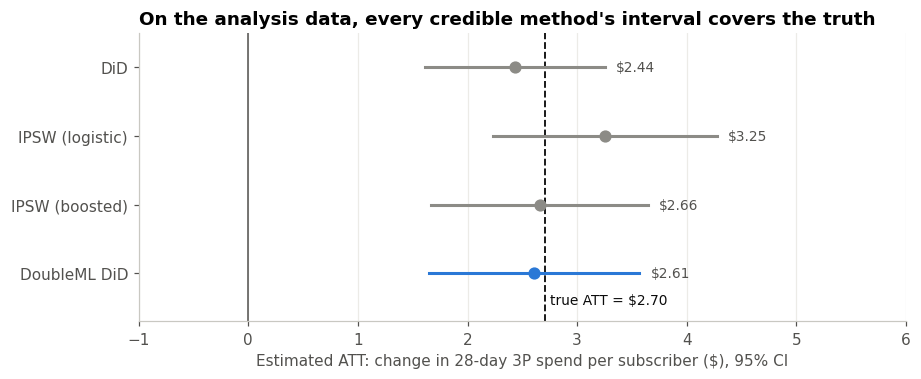

In [3]:
fig, ax = plt.subplots(figsize=(9, 3.4))
forest(ax, ests, "DoubleML DiD", xlim=(-1, 6))
ax.axvline(TRUE_ATT, color=TRUTH, lw=1.2, ls="--", zorder=1)
ax.text(TRUE_ATT + 0.05, -0.45, f"true ATT = ${TRUE_ATT:.2f}", color=TRUTH, fontsize=9)
ax.set_ylim(-0.7, len(ests) - 0.5)
ax.set_title("On the analysis data, every credible method's interval covers the truth")
plt.show()

One dataset is an anecdote, though. The rest of the notebook uses a Monte Carlo:
`src/monte_carlo.py` simulates 8 fresh datasets of 1M users per scenario and runs DiD,
boosted IPSW, and DoubleML DiD on each (about 25 minutes, so the results are saved to
`data/monte_carlo.csv`).

In [4]:
mc = pd.read_csv("data/monte_carlo.csv")
mc["rel_error"] = mc.estimate / mc.true_att - 1
mc["ci_halfwidth"] = 1.96 * mc.se
methods = ["DiD", "IPSW (boosted)", "DoubleML DiD"]
scenarios = ["main", "seasonal_shock", "latent_selection"]

summary = (mc.groupby(["scenario", "method"])
             .agg(mean_rel_bias=("rel_error", "mean"), sd_rel_error=("rel_error", "std"),
                  ci_halfwidth=("ci_halfwidth", "mean"), ci_coverage=("covered", "mean"),
                  pre_trend=("pre_trend", "mean"), pre_trend_se=("pre_trend_se", "mean"))
             .reindex(pd.MultiIndex.from_product([scenarios, methods])))
summary

mean_rel_bias  sd_rel_error  ci_halfwidth  \
main             DiD                     0.075         0.118         0.789   
                 IPSW (boosted)          0.120         0.104         0.976   
                 DoubleML DiD            0.126         0.121         0.950   
seasonal_shock   DiD                     1.004         0.176         0.857   
                 IPSW (boosted)          0.088         0.235         1.053   
                 DoubleML DiD            0.069         0.249         1.021   
latent_selection DiD                     0.043         0.120         1.433   
                 IPSW (boosted)          0.557         0.123         1.634   
                 DoubleML DiD            0.559         0.152         1.626   

                                 ci_coverage  pre_trend  pre_trend_se  
main             DiD                   1.000     -0.382         0.376  
                 IPSW (boosted)        1.000     -0.382         0.376  
                 DoubleML DiD          0.875     -0.382         0.376  
seasonal_shock   DiD                   0.000     -0.382         0.376  
                 IPSW (boosted)        0.750     -0.382         0.376  
                 DoubleML DiD          0.750     -0.382         0.376  
latent_selection DiD                   1.000     -0.405         0.683  
                 IPSW (boosted)        0.125     -0.405         0.683  
                 DoubleML DiD          0.125     -0.405         0.683

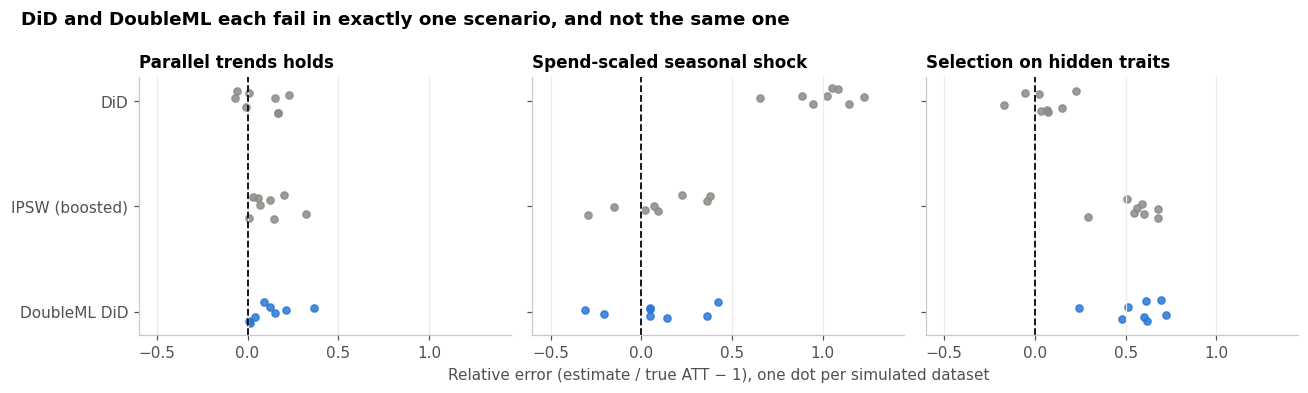

In [5]:
titles = {
    "main": "Parallel trends holds",
    "seasonal_shock": "Spend-scaled seasonal shock",
    "latent_selection": "Selection on hidden traits",
}
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
rng = np.random.default_rng(0)
for ax, scn in zip(axes, scenarios):
    for yi, m in zip(np.arange(len(methods))[::-1], methods):
        vals = mc.query("scenario == @scn and method == @m").rel_error.to_numpy()
        color = TREATED if m == "DoubleML DiD" else CONTROL
        ax.scatter(vals, yi + rng.uniform(-0.12, 0.12, len(vals)), s=22, color=color, alpha=0.85)
    ax.axvline(0, color=TRUTH, lw=1.2, ls="--")
    ax.set_title(titles[scn], fontsize=11)
    ax.set_xlim(-0.6, 1.45)
    ax.grid(axis="y", visible=False)
axes[0].set_yticks(np.arange(len(methods))[::-1], methods)
axes[1].set_xlabel("Relative error (estimate / true ATT − 1), one dot per simulated dataset")
fig.suptitle("DiD and DoubleML each fail in exactly one scenario, and not the same one",
             x=0.02, ha="left", fontweight="bold")
plt.tight_layout()
plt.show()

## 2. When parallel trends holds: no free precision

In the `main` scenario, all three methods land close to the truth. DiD is closest, and
boosted IPSW and DoubleML run slightly high on average. With 8 datasets, each average
is uncertain by about ±4 percentage points, so treat small differences between them
with care. The clearer difference is precision: DiD has the narrowest intervals.

In [6]:
summary.loc["main", ["mean_rel_bias", "ci_halfwidth", "ci_coverage"]]

,mean_rel_bias,ci_halfwidth,ci_coverage
DiD,0.075,0.789,1.000
IPSW (boosted),0.120,0.976,1.000
DoubleML DiD,0.126,0.950,0.875


Covariate adjustment usually buys precision in experiments (CUPED is the same idea), but
it only helps if the covariates predict the outcome. Here the outcome is a 28-day spend
change dominated by whale noise that no pre-period covariate can predict, and the
propensity weights add variance of their own. So when parallel trends truly holds,
**DiD is the more efficient estimator in this data**. The case for DoubleML has to rest
on robustness, not precision.

## 3. Spend-scaled seasonal shock: DiD fails, and the pre-trend test can't see it

The post period gets a seasonal lift of the same *percentage* for everyone, so in
dollars it's largest for the heaviest spenders. Subscribers spend about four times as
much, so they absorb about four times the shock, and DiD books it as subscription
effect. Nothing happened before launch, so the pre-trend test sees exactly what it
sees in the main scenario (the `pre_trend` columns above are identical; only the post
period differs).

A side note on that column: the pre-trend coefficient is slightly negative on average,
and the test rejected in 2 of 8 datasets in both of those scenarios. The cause is new
buyers: their pre2 spend is zero by definition, and they're somewhat more common among
subscribers. That's a real pre-period difference that doesn't carry into the post
period, so DiD stays accurate. A failed pre-trend test is a reason to investigate, not
automatically a verdict.

Would the analysis notebook's indirect check (spend change among non-subscribers, by
pre2 spend) have caught it? Here it is on one seasonal-shock dataset next to the analysis
data:

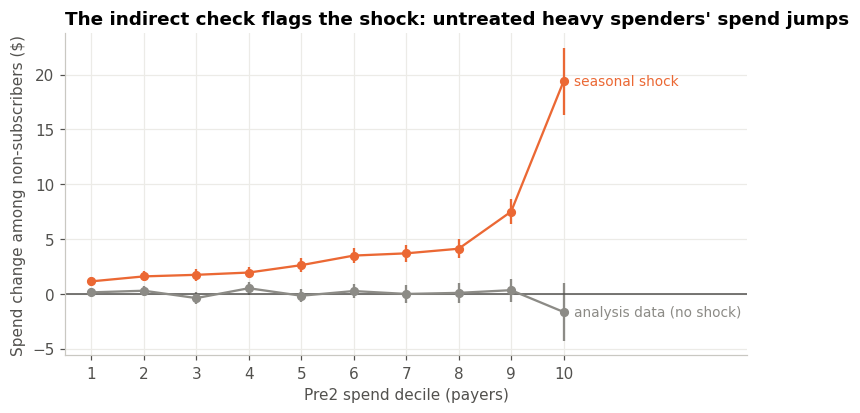

In [7]:
obs_season, _ = simulate(seed=SEED, scenario="seasonal_shock")

fig, ax = plt.subplots(figsize=(8, 3.8))
for data, color, label in [(obs, CONTROL, "analysis data (no shock)"),
                           (obs_season, ALT, "seasonal shock")]:
    prof = D.control_change_by(data[data["3p_spend_pre2"] > 0], "3p_spend_pre2")
    xx = np.arange(len(prof))
    ax.errorbar(xx, prof["mean"], yerr=1.96 * prof["sem"], fmt="o-", color=color, ms=5,
                elinewidth=1.5, lw=1.5)
    ax.text(xx[-1] + 0.2, prof["mean"].iloc[-1], label, color=color, va="center", fontsize=9)
ax.axhline(0, color=INK_2, lw=1)
ax.set_xticks(xx, [str(i + 1) for i in xx])
ax.set_xlim(-0.5, len(xx) + 2.5)
ax.set_xlabel("Pre2 spend decile (payers)")
ax.set_ylabel("Spend change among non-subscribers ($)")
ax.set_title("The indirect check flags the shock: untreated heavy spenders' spend jumps")
plt.show()

Yes: under the shock, non-subscribers' spend change rises steeply with how much they
spend. Seeing that profile is the signal to distrust DiD's unconditional comparison.
DoubleML compares subscribers with non-subscribers who have the same covariates, so the
shock cancels out.

## 4. Selection on hidden traits: DoubleML fails, DiD doesn't

Here users subscribe based on their *underlying* purchase rate and game affinity, which
the data only reflects through noisy pre-period spend. Parallel trends holds, so DiD is
fine. DoubleML conditions on pre-period spend, and that's the problem: among users with
the *same* pre-period spend, subscribers tend to have a higher underlying rate (that's
why they subscribed), so their spend was less inflated by luck and regresses less.
DoubleML reads that as subscription effect. This is the regression-to-the-mean trap in
matching on pre-period outcomes (Daw & Hatfield, 2018).

The analysis notebook's check: does pre-period spend predict subscription beyond
engagement and device?

In [8]:
obs_latent, _ = simulate(seed=SEED, scenario="latent_selection")
sets = {"engagement + device": ["l28d_app_sessions", "premium_device"],
        "all pre-period covariates": E.COVARIATES}
pd.DataFrame({
    "analysis data": D.selection_auc(obs, sets),
    "selection on hidden traits": D.selection_auc(obs_latent, sets),
}).T.assign(**{"AUC gain from spend history": lambda t: t.iloc[:, 1] - t.iloc[:, 0]})

,engagement + device,all pre-period covariates,AUC gain from spend history
analysis data,0.690,0.690,-0.000
selection on hidden traits,0.693,0.736,0.043


In the analysis data, spend history adds nothing. Under selection on hidden traits it
adds about four AUC points. That's modest in absolute terms, but the contrast with zero
is the signal: subscription is tracking something about spending that engagement
doesn't capture. That's the warning that conditioning on pre-period spend may mislead,
and that DiD (if its pre-trend test passes) is the safer estimate. Note that the check
is directional, not a threshold: it tells you which way to lean, not how big the bias is.

## 5. Summary: when to prefer which

In [9]:
rows = {}
for m in methods:
    rows[m] = {f"{titles[s]}: bias / coverage":
               f"{summary.loc[(s, m), 'mean_rel_bias']:+.0%} / {summary.loc[(s, m), 'ci_coverage']:.0%}"
               for s in scenarios}
pd.DataFrame(rows).T

,Parallel trends holds: bias / coverage,Spend-scaled seasonal shock: bias / coverage,Selection on hidden traits: bias / coverage
DiD,+7% / 100%,+100% / 0%,+4% / 100%
IPSW (boosted),+12% / 100%,+9% / 75%,+56% / 12%
DoubleML DiD,+13% / 88%,+7% / 75%,+56% / 12%


| What the diagnostics show | Prefer | Why |
|---|---|---|
| Pre-trend passes; untreated spend change flat across spend levels; spend history adds little to predicting treatment | Either, and report both | Neither threat shows up. DiD is tighter; DoubleML guards against a shock you can only rule out indirectly |
| Untreated spend change rises with spend level | **DoubleML** | A spend-scaled post-period shock breaks unconditional parallel trends |
| Spend history strongly predicts treatment beyond engagement | **DiD** (if its pre-trend test passes) | Conditioning on noisy pre-period spend reintroduces regression to the mean |
| Both warning signs at once | Neither is safe | This is where a randomized holdout is the only credible answer |

The analysis data is the first row, which is why `01_analysis.ipynb` reports DoubleML as
the headline with DiD alongside: the two methods fail under different threats, and their
agreement is what makes the estimate credible.